# Task 7 - Customer segmentation (RFM)
**RFM** describes every customer with three numbers:
* **R**ecency - days since their last order (lower = better)
* **F**requency - number of orders (merged shopping trips, see below)
* **M**onetary - total spent

R and M are scored 1-5 (5 = best, by quintile). Frequency is capped at 3 because 97% of customers ordered only once.

In [ ]:
import os, sys

# Notebooks live in Jupyters/, code lives in src/  ->  always run from the project root
if os.path.basename(os.getcwd()) == "Jupyters":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
assert os.path.exists("olist.db"), f"olist.db not found in {os.getcwd()} - launch Jupyter from the project root"

import pandas as pd
from IPython.display import Image, display
from src.data_loader import get_connection

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
conn = get_connection()
from src.data_prep import trip_summary
print(trip_summary(conn, gap_hours=1.0))
from src.segmentation import *

##  Compute RFM

In [4]:
rfm = compute_rfm(conn, merge_gap_hours=1.0)
print("customers:", len(rfm), "| 'today' =", rfm.attrs["snapshot"].date())
rfm.head()

customers: 93358 | 'today' = 2018-08-30


,customer_unique_id,last_purchase,frequency,monetary,recency_days,avg_order_value
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,129.90,111,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,18.90,114,18.90
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,69.00,537,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,25.99,321,25.99
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,180.00,288,180.00


## 2. Score and assign segments

In [5]:
segmented = add_segments(rfm)
profile = segment_profile(segmented)
profile

,customers,avg_recency_days,avg_orders,avg_spend,avg_order_value,total_revenue,pct_customers,pct_revenue
segment,,,,,,,,
Champions,844,86.8,2.2,329.7,152.9,278234.6,0.9,2.1
Loyal repeat,1201,266.0,2.1,228.9,110.5,274923.2,1.3,2.1
High-value new,21683,133.3,1.0,261.7,261.7,5675168.4,23.2,42.9
At-risk high-value,14061,394.3,1.0,277.4,277.4,3899861.9,15.1,29.5
Recent one-timers,32880,133.4,1.0,55.5,55.5,1826221.0,35.2,13.8
Lapsed one-timers,22689,394.8,1.0,55.8,55.8,1267088.9,24.3,9.6


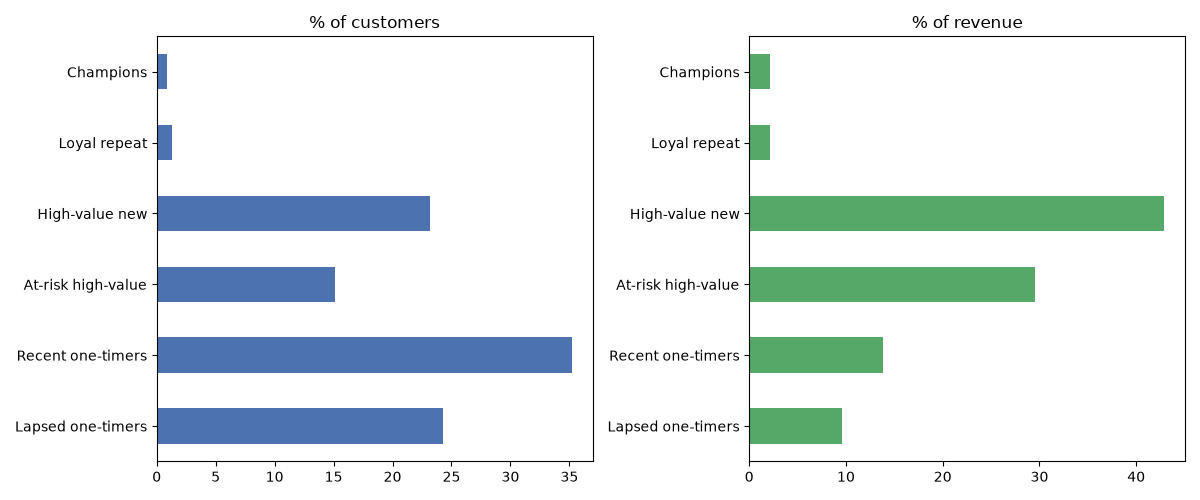

In [6]:
Image(save_segment_chart(profile))

## 3. Cross-check with KMeans
Cluster on log-scaled, standardised R/F/M. The silhouette score picks k.

In [7]:
clustered, k, silhouettes = kmeans_segments(segmented)
print("chosen k:", k, "| silhouette by k:", {a: round(b, 3) for a, b in silhouettes.items()})
clustered.groupby("cluster").agg(customers=("cluster", "size"), recency=("recency_days", "mean"),
                                 orders=("frequency", "mean"), spend=("monetary", "mean")).round(1)

chosen k: 3 | silhouette by k: {3: 0.414, 4: 0.391, 5: 0.349, 6: 0.349}


,customers,recency,orders,spend
cluster,,,,
0,72133,289.2,1.0,138.8
1,19180,47.8,1.0,138.6
2,2045,192.1,2.1,270.5


In [8]:
cluster_vs_segment(clustered)

segment,Champions,Loyal repeat,High-value new,At-risk high-value,Recent one-timers,Lapsed one-timers
cluster,,,,,,
0,0.0,0.0,19.6,19.5,29.4,31.5
1,0.0,0.0,39.3,0.0,60.7,0.0
2,41.3,58.7,0.0,0.0,0.0,0.0


In [9]:
# k=4 recovers the same spend x recency structure as the rules
c4, _, _ = kmeans_segments(segmented, k=4)
c4.groupby("cluster").agg(customers=("cluster", "size"), recency=("recency_days", "mean"),
                          orders=("frequency", "mean"), spend=("monetary", "mean")).round(1)

,customers,recency,orders,spend
cluster,,,,
0,36975,283.3,1.0,45.3
1,16042,41.1,1.0,117.2
2,38296,277.9,1.0,238.0
3,2045,192.1,2.1,270.5


### Reading the cross-check
* Confirm whether KMeans (best silhouette) still isolates repeat customers as
  their own cluster, matching Champions + Loyal repeat — re-verify this after
  the trip-merge fix, since repeat-customer counts shifted.
* With k=4, check whether one-time customers still split into recent / big-old
  / small-old, mirroring the rules (recency x spend).
* The rules stay as the segmentation of record because they are explainable
  and stable; KMeans confirms they are not arbitrary.

Feeds **Task 8** - every promo is attached to one of these segments.